### Overview
##### Welcome to the 2026 Kaggle Playground Series! We plan to continue in the spirit of previous playgrounds, providing interesting and approachable datasets for our community to practice their machine learning skills, and anticipate a competition each month.

##### Goal: Predict whether a Formula 1 driver will pit on the next lap.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


Load Dataset

In [2]:
dft=pd.read_csv('train.csv')
dft.head()
dfte=pd.read_csv('test.csv')
dfte.head()


,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change
0,439140,D119,MEDIUM,British Grand Prix,2023,0,21,1,21.0,4,93.387,0.280,-4.984,0.403846,0.0
1,439141,VER,MEDIUM,Abu Dhabi Grand Prix,2023,0,24,1,24.0,1,90.867,-0.129,-1.990,0.413793,0.0
2,439142,D270,MEDIUM,British Grand Prix,2023,0,24,1,24.0,11,92.871,0.041,-8.842,0.461538,0.0
3,439143,D112,SOFT,São Paulo Grand Prix,2024,0,6,2,4.0,15,94.967,-19.741,8.250,0.077922,1.0
4,439144,AND,HARD,United States Grand Prix,2024,0,52,2,29.0,12,99.112,0.930,-20.848,0.722222,7.0


Exploratory Data Analysis

In [3]:
dft.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 439140 entries, 0 to 439139
Data columns (total 16 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      439140 non-null  int64  
 1   Driver                  439140 non-null  object 
 2   Compound                439140 non-null  object 
 3   Race                    439140 non-null  object 
 4   Year                    439140 non-null  int64  
 5   PitStop                 439140 non-null  int64  
 6   LapNumber               439140 non-null  int64  
 7   Stint                   439140 non-null  int64  
 8   TyreLife                439140 non-null  float64
 9   Position                439140 non-null  int64  
 10  LapTime (s)             439140 non-null  float64
 11  LapTime_Delta           439140 non-null  float64
 12  Cumulative_Degradation  439140 non-null  float64
 13  RaceProgress            439140 non-null  float64
 14  Position_Change     

In [4]:
dft.describe()

,id,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
count,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000
mean,219569.500000,2023.523544,0.136118,23.105909,1.789113,14.158231,9.630339,90.948735,-3.770040,-25.721759,0.337661,0.101542,0.198982
std,126768.942943,1.024930,0.342915,16.958261,0.950194,9.801338,5.278770,19.772769,43.945759,54.766573,0.253277,4.006765,0.399235
min,0.000000,2022.000000,0.000000,1.000000,1.000000,1.000000,1.000000,67.694000,-2403.895000,-274.564000,0.012821,-18.000000,0.000000
25%,109784.750000,2023.000000,0.000000,9.000000,1.000000,6.000000,5.000000,82.621000,-8.884000,-46.566250,0.129870,-1.000000,0.000000
50%,219569.500000,2024.000000,0.000000,19.000000,2.000000,12.000000,10.000000,90.521000,-0.295000,-20.994000,0.269231,0.000000,0.000000
75%,329354.250000,2024.000000,0.000000,36.000000,2.000000,20.000000,14.000000,98.471000,0.115000,-6.199000,0.513158,2.000000,0.000000
max,439139.000000,2025.000000,1.000000,78.000000,8.000000,77.000000,20.000000,2507.607000,2423.932000,2412.026000,1.000000,18.000000,1.000000


In [5]:
dft.columns

Index(['id', 'Driver', 'Compound', 'Race', 'Year', 'PitStop', 'LapNumber',
       'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta',
       'Cumulative_Degradation', 'RaceProgress', 'Position_Change',
       'PitNextLap'],
      dtype='object')


- **id**: Unique identifier for each lap record.  
- **Driver**: Name or code of the Formula 1 driver.  
- **Compound**: Tyre compound used (Soft, Medium, Hard, etc.).  
- **Race**: Name or identifier of the race.  
- **Year**: Year in which the race took place.  
- **PitStop**: Number of pit stops completed so far.  
- **LapNumber**: Current lap number in the race.  
- **Stint**: Stint number (period between pit stops).  
- **TyreLife**: Age of the tyre in laps since last pit stop.  
- **Position**: Driver’s current race position.  
- **LapTime (s)**: Time taken to complete the lap (in seconds).  
- **LapTime_Delta**: Difference compared to the previous lap time.  
- **Cumulative_Degradation**: Measure of tyre wear accumulated over laps.  
- **RaceProgress**: Percentage of race completed (0–100%).  
- **Position_Change**: Change in race position compared to the previous lap.  
- **PitNextLap**: Target variable → 1 if the driver pits on the next lap, 0 otherwise.

In [6]:
Y=dft.PitNextLap
Y

0         1.0
1         0.0
2         1.0
3         0.0
4         0.0
         ... 
439135    0.0
439136    0.0
439137    0.0
439138    0.0
439139    0.0
Name: PitNextLap, Length: 439140, dtype: float64

In [7]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
## Encode Categorical Variables
dft['Compound_LE']=le.fit_transform(dft.Compound)
dfte['Compound_LE']=le.fit_transform(dfte.Compound)
dft['Race_LE']=le.fit_transform(dft.Race)
dfte['Race_LE']=le.fit_transform(dfte.Race)


In [8]:
## scale continous features
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
dft['LapTime (s)']=sc.fit_transform(dft[['LapTime (s)']])
dft['LapTime_Delta']=sc.fit_transform(dft[['LapTime_Delta']])
dft['Cumulative_Degradation']=sc.fit_transform(dft[['Cumulative_Degradation']])
dfte['LapTime (s)']=sc.fit_transform(dfte[['LapTime (s)']])
dfte['LapTime_Delta']=sc.fit_transform(dfte[['LapTime_Delta']])
dfte['Cumulative_Degradation']=sc.fit_transform(dfte[['Cumulative_Degradation']])

dft.describe(include='all')

,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap,Compound_LE,Race_LE
count,439140.000000,439140,439140,439140,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,4.391400e+05,4.391400e+05,4.391400e+05,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000
unique,NaN,887,5,26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,MAS,MEDIUM,Dutch Grand Prix,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,1682,211141,24462,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,219569.500000,NaN,NaN,NaN,2023.523544,0.136118,23.105909,1.789113,14.158231,9.630339,1.441408e-15,5.970539e-18,-1.317078e-17,0.337661,0.101542,0.198982,1.278217,12.781821
std,126768.942943,NaN,NaN,NaN,1.024930,0.342915,16.958261,0.950194,9.801338,5.278770,1.000001e+00,1.000001e+00,1.000001e+00,0.253277,4.006765,0.399235,1.082766,7.538204
min,0.000000,NaN,NaN,NaN,2022.000000,0.000000,1.000000,1.000000,1.000000,1.000000,-1.176100e+00,-5.461568e+01,-4.543694e+00,0.012821,-18.000000,0.000000,0.000000,0.000000
25%,109784.750000,NaN,NaN,NaN,2023.000000,0.000000,9.000000,1.000000,6.000000,5.000000,-4.211724e-01,-1.163699e-01,-3.806065e-01,0.129870,-1.000000,0.000000,0.000000,6.000000
50%,219569.500000,NaN,NaN,NaN,2024.000000,0.000000,19.000000,2.000000,12.000000,10.000000,-2.163253e-02,7.907576e-02,8.632573e-02,0.269231,0.000000,0.000000,2.000000,13.000000
75%,329354.250000,NaN,NaN,NaN,2024.000000,0.000000,36.000000,2.000000,20.000000,14.000000,3.804360e-01,8.840546e-02,3.564726e-01,0.513158,2.000000,0.000000,2.000000,19.000000


Feature Engineering


In [9]:
##label encode Driver Name
dft['Driver_Code']=le.fit_transform(dft['Driver'])
dfte['Driver_Code']=le.fit_transform(dfte['Driver'])


<Axes: xlabel='Compound', ylabel='TyreLife'>

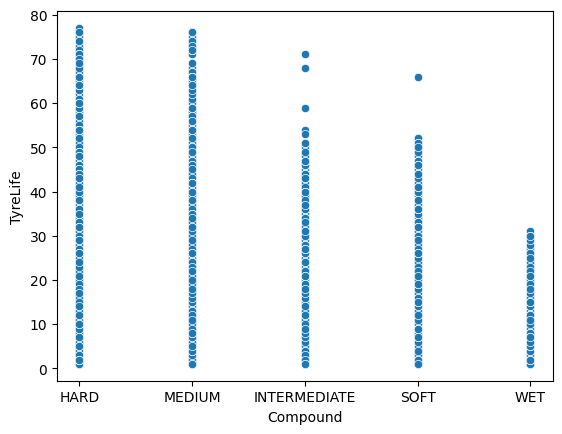

In [10]:
sns.scatterplot(data=dft,y='TyreLife',x='Compound')

<Axes: xlabel='PitStop', ylabel='count'>

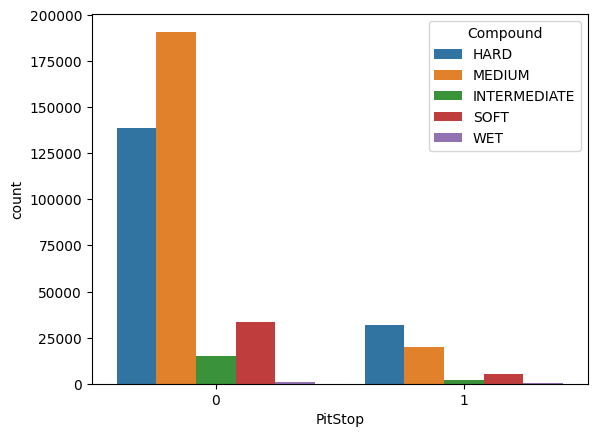

In [11]:
sns.countplot(data=dft,x='PitStop',hue='Compound')

In [12]:
dft.columns

Index(['id', 'Driver', 'Compound', 'Race', 'Year', 'PitStop', 'LapNumber',
       'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta',
       'Cumulative_Degradation', 'RaceProgress', 'Position_Change',
       'PitNextLap', 'Compound_LE', 'Race_LE', 'Driver_Code'],
      dtype='object')

In [13]:
X=dft[["Compound_LE", "Driver_Code", "Race_LE", "LapNumber", "Stint",
    "TyreLife", "PitStop", "LapTime (s)", "LapTime_Delta",
    "Cumulative_Degradation", "RaceProgress", "Position", "Position_Change"
]]
x=dfte[["Compound_LE", "Driver_Code", "Race_LE", "LapNumber", "Stint",
    "TyreLife", "PitStop", "LapTime (s)", "LapTime_Delta",
    "Cumulative_Degradation", "RaceProgress", "Position", "Position_Change"]]
Y=dft.PitNextLap
## y=dfte.PitNextLap
X

,Compound_LE,Driver_Code,Race_LE,LapNumber,Stint,TyreLife,PitStop,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position,Position_Change
0,0,134,7,50,2,39.0,0,-0.630046,-0.086333,0.853455,0.714286,8,5.0
1,0,111,9,27,2,7.0,1,-0.801797,-0.656423,-3.605949,0.346154,4,-3.0
2,0,886,2,59,3,22.0,0,-1.011682,-0.085787,-1.365930,0.819444,13,3.0
3,2,864,19,2,1,2.0,0,0.172574,-0.080872,0.335931,0.076923,7,0.0
4,0,44,3,26,3,6.0,1,0.856192,0.289790,0.211493,0.361111,2,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
439135,2,780,17,49,2,8.0,0,0.085434,0.084059,0.180087,0.859649,17,0.0
439136,2,756,17,49,2,5.0,0,-0.255844,0.083900,0.380064,0.859649,1,0.0
439137,2,741,17,49,2,18.0,0,0.035163,0.081647,-0.559635,0.942308,1,0.0
439138,0,690,0,48,3,10.0,0,-0.050662,0.085766,0.091311,0.827586,1,1.0


In [14]:
from sklearn.decomposition import PCA
pac=PCA(0.95)
x_pac=pac.fit_transform(X)
x_pac2=pac.fit_transform(x)
x_pac2.shape

(188165, 1)

In [15]:
## logisitc regression
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression(max_iter=1000)
lr.fit(X,Y)

c:\Users\EMMANUEL\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [16]:
prediction=lr.predict(x)
prediction

array([0., 0., 0., ..., 0., 0., 0.], shape=(188165,))

In [17]:
dfte['PitNextLap']=lr.predict(x)
dfte['PitNextLap'].value_counts()

PitNextLap
0.0    172661
1.0     15504
Name: count, dtype: int64

In [18]:
Sub=dfte[['id','PitNextLap']].reset_index(drop=True)
Sub.to_csv('submission.csv',index=False)

In [19]:
## random Forest
from sklearn.ensemble import RandomForestClassifier
rfc=RandomForestClassifier(n_estimators=100)

rfc.fit(X,Y)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [20]:
rfc.predict(x)

array([0., 0., 0., ..., 1., 1., 0.], shape=(188165,))

In [23]:
dfte['PitNextLapRF']=rfc.predict(x)

In [24]:
Sub_rf=dfte[['id','PitNextLapRF']].reset_index(drop=True)
Sub_rf.to_csv('submission_rf.csv',index=False)